In [1]:
using Pkg
Pkg.activate("..")

  Activating project at `~/julia/ViscousStreaming.jl`


In [2]:
using Revise
using ViscousStreaming

[ Info: Precompiling ViscousStreaming [47fb7046-13b0-40db-b6a6-74fa44cf0959] (cache misses: include_dependency fsize change (2))


In [3]:
using Plots

In [4]:
# markdown display disable
import Markdown
Base.showable(::MIME"text/markdown", ::Markdown.MD) = false

In [5]:
DDF_TYPE = CartesianGrids.Yang3

CartesianGrids.Yang3

In [6]:
Re = 40

40

In [7]:
spacing = 1.4 
Δx = 0.02
Lx = 5.98*2
xlim = (-Lx/2,Lx/2)
ylim = (-Lx/2,Lx/2)
g = PhysicalGrid(xlim,ylim,Δx;nthreads_max=4)
Δs = spacing*cellsize(g)
body = Circle(1.0, Δs)
# body = Square(1.0, Δs)
cache = SurfaceVectorCache(body, g)

Surface cache with scaling of type GridScaling
  224 point data of type VectorData{224, Float64, Vector{Float64}}
  Grid data of type Edges{Primal, 600, 600, Float64, Vector{Float64}}


In [8]:
my_params = Dict()
my_params["Re"] = Re;

In [9]:
function get_vsplus1(base_cache,phys_params)
    vsplus = zeros_surface(base_cache)
    vsplus.u .= 1
    return vsplus
end
function get_vsminus1(base_cache,phys_params)
    vsminus = zeros_surface(base_cache)
    vsminus.u .= 1
    return vsminus
end

bcdict1 = Dict("exterior"=>get_vsplus1,"interior"=>get_vsminus1);

In [10]:
prob = ViscousStreaming.ViscousStreamingInertialProblem(g,body,scaling=GridScaling,bc=bcdict1, dtype=ComplexF64, phys_params = my_params, ddftype=DDF_TYPE)
@time sys = construct_system(prob);

 54.857871 seconds (18.98 M allocations: 24.127 GiB, 1.99% gc time, 7.33% compilation time)


In [11]:
@time v1, s1, σ1, v2, s2, σ2 = ImmersedLayers.solve(prob,sys)
nothing

  5.414123 seconds (29.61 M allocations: 1.931 GiB, 4.29% gc time, 93.80% compilation time)


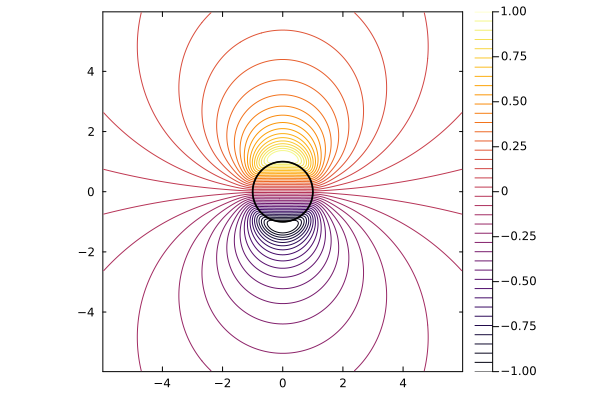

In [12]:
plot(real(s1),sys, levels=range(-1,1,length=40),clim=(-1,1), cbar=true, xlim=(-Lx/2,Lx/2), ylim=(-Lx/2,Lx/2), bodyfill=false)

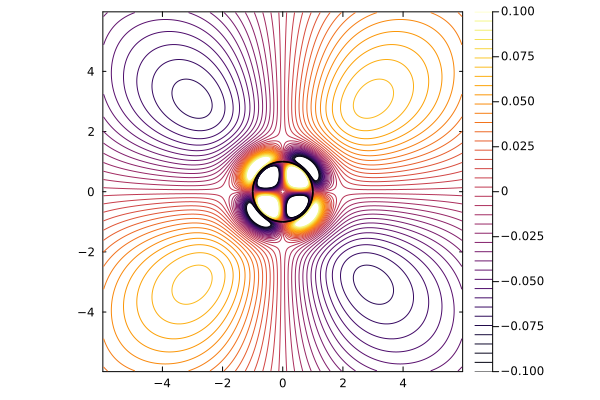

In [13]:
plot(real(s2),sys, levels=range(-0.1,0.1,length=40),clim=(-0.1,0.1), cbar=true, xlim=(-Lx/2,Lx/2), ylim=(-Lx/2,Lx/2), bodyfill=false)

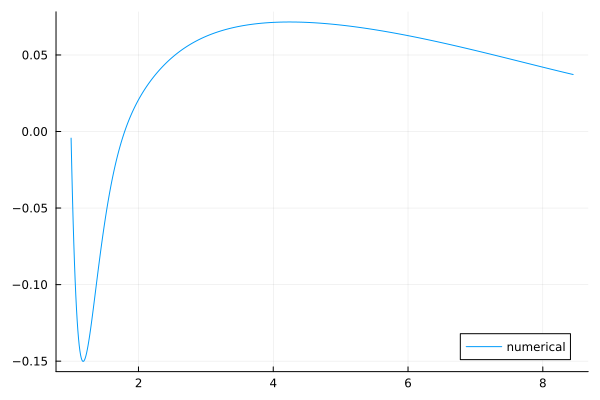

In [14]:
s2_itp = interpolatable_field(real(s2), sys);
r = 1:0.01:Lx/sqrt(2)
plot(r, s2_itp.(r/sqrt(2), r/sqrt(2)), label="numerical")